# Focal Loss

In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import pickle

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-08 07:52:57.649797: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-08 07:52:57.649867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-08 07:52:57.651366: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-08 07:52:57.657813: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6


2026-06-08 07:52:59.356207: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:52:59.365482: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:52:59.365528: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:52:59.365829: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


TensorFlow version: 2.15.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
organized_base = pathlib.Path("/tf/work/data/organized_dataset")
train_dir = organized_base / "Train"
val_dir = organized_base / "Validation"
test_dir = organized_base / "Test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")

Found 49376 images belonging to 15 classes.
Found 10584 images belonging to 15 classes.
Found 10589 images belonging to 15 classes.
Train: 49376, Val: 10584, Test: 10589


In [3]:
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * (1 - y_pred)**gamma
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

In [4]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()

2026-06-08 07:53:02.276683: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:53:02.276815: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:53:02.276875: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:53:02.524727: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 07:53:02.524790: I external/local_xla/xla/stream_executor

58889256/58889256 [==============================] - 15s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 15)                7695      
                                                                 
Total params: 14722383 (56.16 MB)
Trainable params: 7695 (30.

In [5]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_gen.samples // BATCH_SIZE,
    callbacks=callbacks,
    workers=4,
    use_multiprocessing=True
)

with open('history_focal.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/20


2026-06-08 07:53:25.381076: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906


   1/6172 [..............................] - ETA: 7:21:53 - loss: 0.6576 - accuracy: 0.0000e+00

2026-06-08 07:53:28.378952: I external/local_xla/xla/service/service.cc:168] XLA service 0x70ee5e086fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-08 07:53:28.379009: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-08 07:53:28.395438: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780905208.492525     558 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6172/6172 [==============================] - 243s 39ms/step - loss: 0.3791 - accuracy: 0.3961 - val_loss: 0.2644 - val_accuracy: 0.5308 - lr: 1.0000e-04
Epoch 2/20
6172/6172 [==============================] - 248s 40ms/step - loss: 0.2556 - accuracy: 0.5520 - val_loss: 0.1919 - val_accuracy: 0.6539 - lr: 1.0000e-04
Epoch 3/20
6172/6172 [==============================] - 248s 40ms/step - loss: 0.2062 - accuracy: 0.6239 - val_loss: 0.1535 - val_accuracy: 0.7029 - lr: 1.0000e-04
Epoch 4/20
6172/6172 [==============================] - 232s 38ms/step - loss: 0.1773 - accuracy: 0.6662 - val_loss: 0.1323 - val_accuracy: 0.7324 - lr: 1.0000e-04
Epoch 5/20
6172/6172 [==============================] - 227s 37ms/step - loss: 0.1599 - accuracy: 0.6865 - val_loss: 0.1170 - val_accuracy: 0.7597 - lr: 1.0000e-04
Epoch 6/20
6172/6172 [==============================] - 233s 38ms/step - loss: 0.1476 - accuracy: 0.7044 - val_loss: 0.1076 - val_accuracy: 0.7701 - lr: 1.0000e-04
Epoch 7/20
6172/6172 [=====

In [6]:
test_loss, test_acc = model.evaluate(test_gen, workers=4, use_multiprocessing=True)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

1324/1324 [==============================] - 31s 23ms/step - loss: 0.0642 - accuracy: 0.8438
Test Accuracy: 0.8438
Test Loss: 0.0642


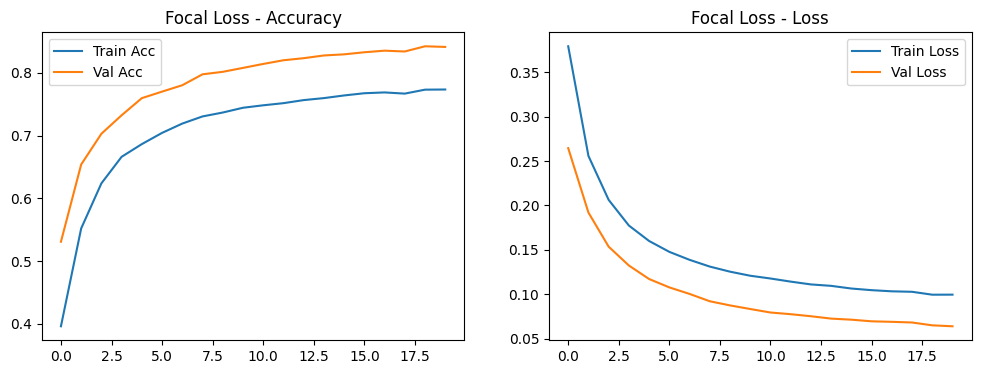

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Focal Loss - Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Focal Loss - Loss')
plt.legend()
plt.show()

1324/1324 [==============================] - 95s 72ms/step

CLASSIFICATION REPORT – FOCAL LOSS
              precision    recall  f1-score   support

       Apple     0.7194    0.6889    0.7038      1678
      Banana     0.9889    0.9802    0.9845       455
   Carambola     0.9899    0.9391    0.9638       312
       Guava     0.8385    0.9631    0.8965      2955
        Kiwi     0.8432    0.9402    0.8891      1270
       Mango     0.8877    0.7981    0.8405       624
      Orange     0.8316    0.8850    0.8574       452
       Peach     0.9155    0.6582    0.7658       395
        Pear     0.7607    0.4712    0.5820       452
   Persimmon     0.9823    0.8939    0.9360       311
      Pitaya     0.9893    0.9814    0.9853       376
        Plum     1.0000    0.9623    0.9808       345
 Pomegranate     0.7949    0.6656    0.7245       326
    Tomatoes     0.7033    0.7270    0.7149       326
   muskmelon     0.8869    0.6282    0.7355       312

    accuracy                         0.

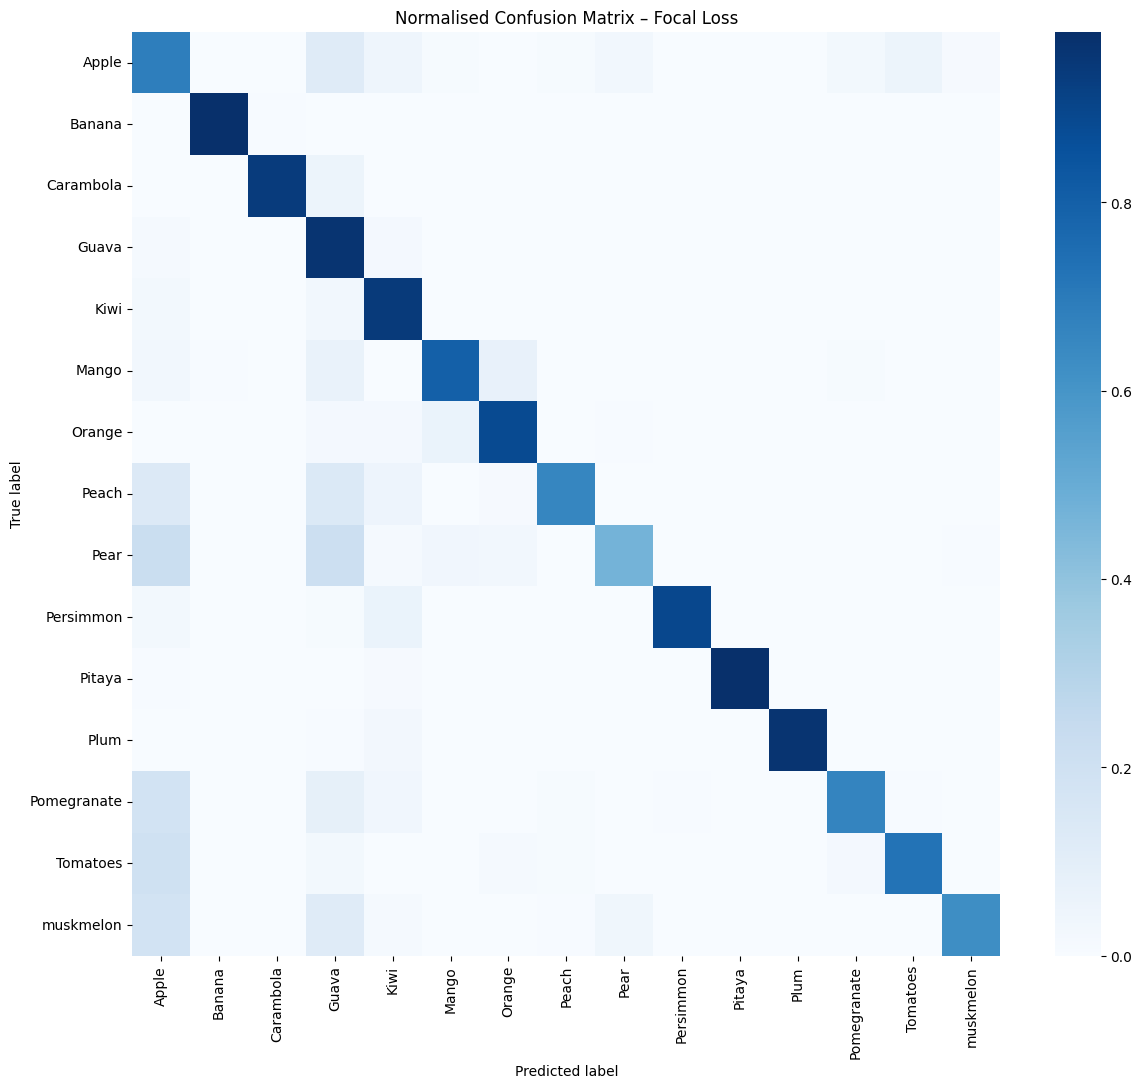

In [8]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\n" + "="*60)
print("CLASSIFICATION REPORT – FOCAL LOSS")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,12))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalised Confusion Matrix – Focal Loss')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [9]:
class_counts = [np.sum(train_gen.classes == i) for i in range(len(class_names))]
recalls = recall_score(y_true, y_pred, average=None)
minority_threshold = 2000
minority_indices = [i for i, cnt in enumerate(class_counts) if cnt < minority_threshold]
minority_recalls = [recalls[i] for i in minority_indices]

print(f"\nMinority classes (<{minority_threshold} images):")
for idx in minority_indices:
    print(f"  {class_names[idx]}: recall = {recalls[idx]:.4f}")
print(f"\nAverage recall on minority classes: {np.mean(minority_recalls):.3f}")
print(f"Average recall on majority classes: {np.mean([recalls[i] for i, cnt in enumerate(class_counts) if cnt >= minority_threshold]):.3f}")


Minority classes (<2000 images):
  Carambola: recall = 0.9391
  Peach: recall = 0.6582
  Persimmon: recall = 0.8939
  Pitaya: recall = 0.9814
  Plum: recall = 0.9623
  Pomegranate: recall = 0.6656
  Tomatoes: recall = 0.7270
  muskmelon: recall = 0.6282

Average recall on minority classes: 0.807
Average recall on majority classes: 0.818


In [10]:
misclassified_indices = np.where(y_pred != y_true)[0]
confusion_pairs = [(y_true[i], y_pred[i]) for i in misclassified_indices]
pair_counts = Counter(confusion_pairs)

print("\n" + "="*60)
print("TOP 5 MOST CONFUSED FRUIT PAIRS (true → predicted)")
print("="*60)
for (true, pred), count in pair_counts.most_common(5):
    print(f"{class_names[true]:15s} → {class_names[pred]:15s} : {count} errors")


TOP 5 MOST CONFUSED FRUIT PAIRS (true → predicted)
Apple           → Guava           : 204 errors
Pear            → Apple           : 101 errors
Pear            → Guava           : 98 errors
Apple           → Tomatoes        : 96 errors
Apple           → Kiwi            : 71 errors
